## Feature engineering & ML 

In [34]:
import pandas as pd
dataset=pd.read_csv("cleaned_ai_layoff_dataset.csv")

In [35]:
# Define the Target Variable
# FEATURES AND TARGET

X = dataset.drop("Layoff_Risk",axis=1) 
y = dataset["Layoff_Risk"]

print(y.value_counts())

Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [37]:
# TRAIN TEST SPLIT
# BEFORE PREPROCESSING
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Encode Categorical Variables
# NUMERIC AND CATEGORICAL FEATURES

numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include="object").columns

print("Numeric Columns:",len(numeric_cols))
print("Categorical Columns:",len(categorical_cols))

Numeric Columns: 9
Categorical Columns: 6


In [39]:
# NUMERIC PIPELINE


numeric_pipeline = Pipeline(

    steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]

)

In [40]:
# CATEGORICAL PIPELINE

categorical_pipeline = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="most_frequent")),
           ("encoder",OneHotEncoder(handle_unknown="ignore"))]
)

In [41]:
# PREPROCESSOR

preprocessor = ColumnTransformer(
    transformers=[("num",numeric_pipeline,numeric_cols),
                  ("cat",categorical_pipeline,categorical_cols)]
)

In [42]:
# MACHINE LEARNING MODELS

models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42 )  } 

results = {}
trained_models = {}

In [43]:
# TRAIN ALL MODELS

for name,model in models.items():
    print(name)

    pipe = Pipeline(
        steps=[("preprocessor",preprocessor),("model",model)]
    )

    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    results[name] = acc
    trained_models[name] = pipe

    print("Accuracy:",round(acc,4))
    print(classification_report(y_test,y_pred))

Logistic Regression
Accuracy: 0.9377
              precision    recall  f1-score   support

        High       0.95      0.96      0.96      1360
         Low       0.95      0.95      0.95      1320
      Medium       0.91      0.90      0.91      1320

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000

Decision Tree
Accuracy: 0.8397
              precision    recall  f1-score   support

        High       0.87      0.88      0.88      1360
         Low       0.88      0.89      0.88      1320
      Medium       0.76      0.75      0.76      1320

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000

Random Forest
Accuracy: 0.9065
              precision    recall  f1-score   support

        High       0.93      0.93      0.93      1360
         Low       0.93      0

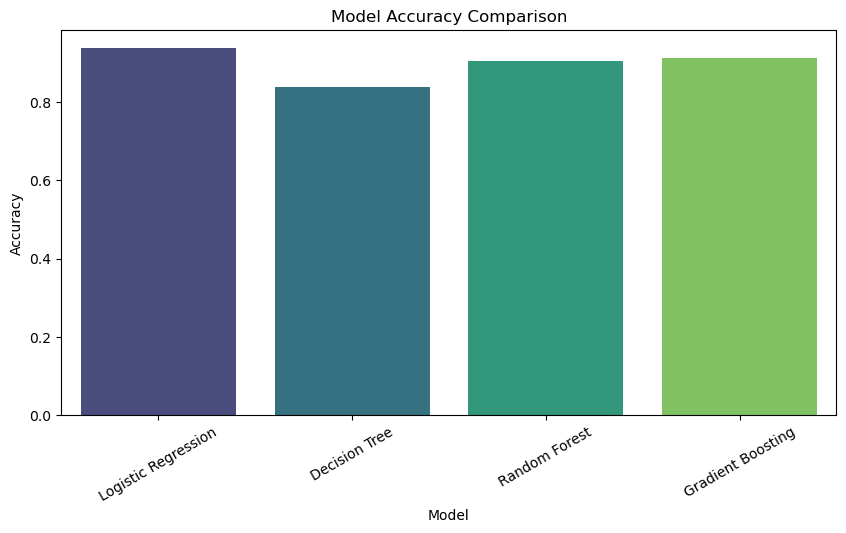

In [44]:
# ACCURACY COMPARISON GRAPH

accuracy_df = pd.DataFrame({
    "Model":list(results.keys()),
    "Accuracy":list(results.values())
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [45]:
# BEST MODEL

best_name = max(
    results,
    key=results.get)

best_model = trained_models[best_name]
print("BEST MODEL:",best_name)

BEST MODEL: Logistic Regression


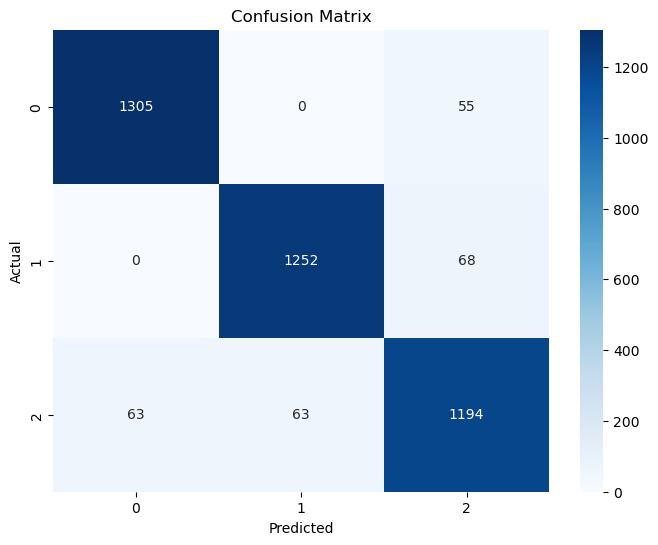

In [46]:
# CONFUSION MATRIX

best_pred = best_model.predict(X_test)
plt.figure(figsize=(8,6))

sns.heatmap(confusion_matrix(y_test,best_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

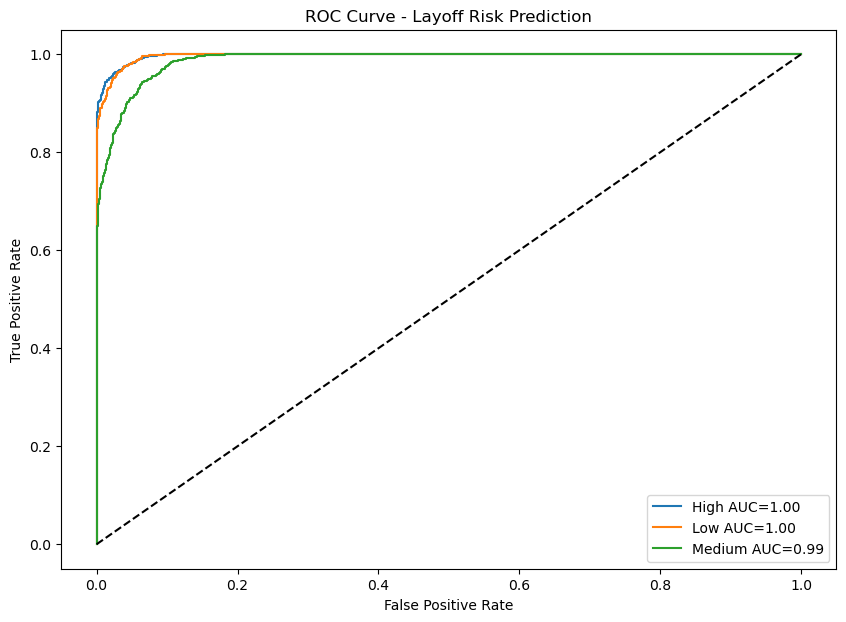

In [47]:
# MULTICLASS ROC CURVE

classes = np.unique(y)

y_test_bin = label_binarize(y_test,classes=classes)
prob = best_model.predict_proba(X_test)

plt.figure(figsize=(10,7))

for i in range(len(classes)):
    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        prob[:,i]
    )

    auc = roc_auc_score(
        y_test_bin[:,i],
        prob[:,i]
    )
    plt.plot(fpr,tpr,label=f"{classes[i]} AUC={auc:.2f}")
    
plt.plot([0,1],[0,1],"k--")

plt.title("ROC Curve - Layoff Risk Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

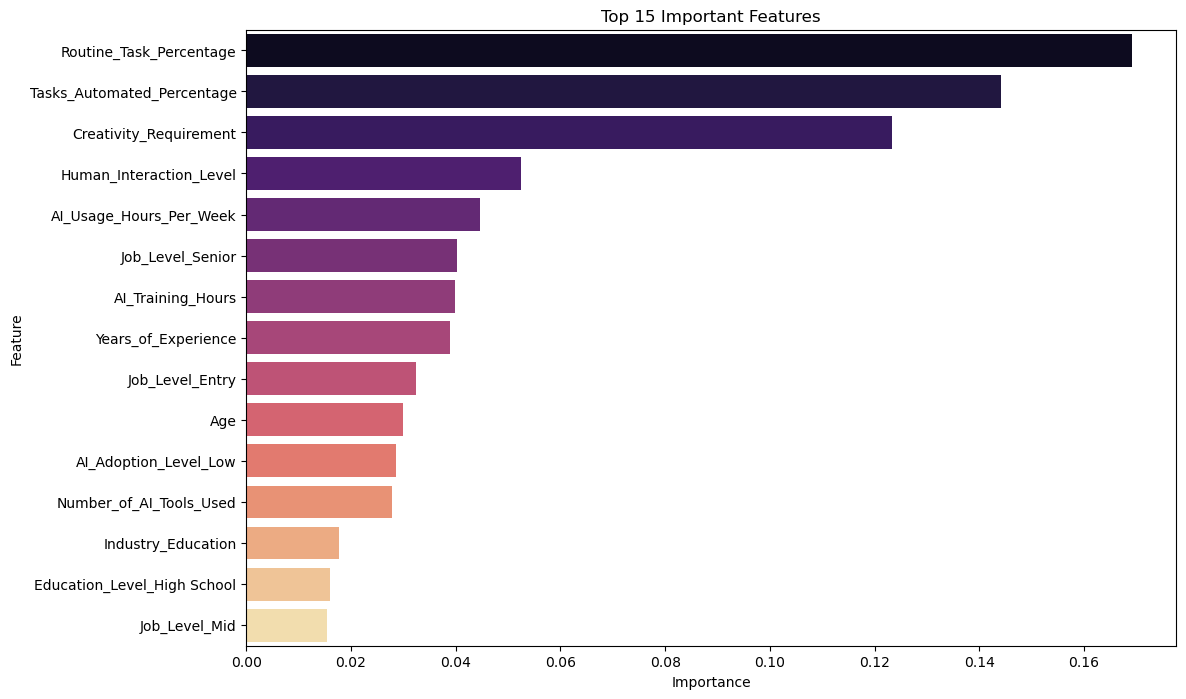

In [28]:
# FEATURE IMPORTANCE
# RANDOM FOREST

rf = trained_models["Random Forest"]

feature_names = (list(numeric_cols)+list(
    rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_cols)
))

importance = pd.DataFrame({"Feature":feature_names,
                           "Importance":rf.named_steps["model"].feature_importances_
})

importance = importance.sort_values("Importance",ascending=False)
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 15 Important Features")
plt.show()

In [33]:
# FINAL RESULT

print("FINAL RESULTS")
print("\n")


for model,score in results.items():
    print(model,":",round(score,4))
    
print('\n')
print("Best Model:",best_name)
print("Best Accuracy:",round(max(results.values()),4))

FINAL RESULTS


Logistic Regression : 0.9377
Decision Tree : 0.8397
Random Forest : 0.9065
Gradient Boosting : 0.9133


Best Model: Logistic Regression
Best Accuracy: 0.9377


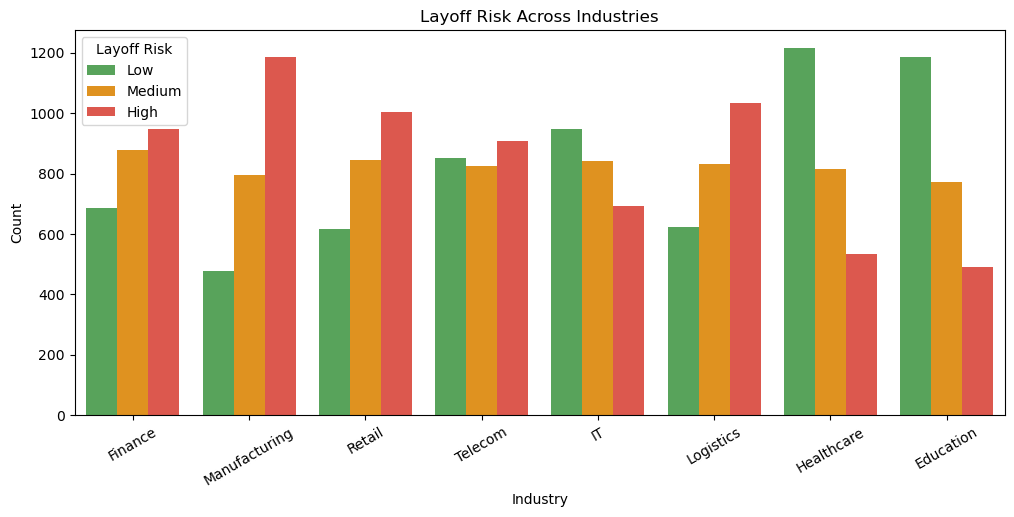

In [48]:
# Layoff Risk Across Industries

plt.figure(figsize=(12, 5))

sns.countplot(
    data=dataset,
    x='Industry',
    hue='Layoff_Risk',
    hue_order=['Low', 'Medium', 'High'],
    palette=['#4CAF50', '#FF9800', '#F44336'])

plt.title('Layoff Risk Across Industries')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.legend(title='Layoff Risk')

plt.xticks(rotation=30)
plt.show()